# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

**First, use the following code snippet to set a plot style close to those used in financial markets.**

---

In [1]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

In [2]:
%pip install lxml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# 1. Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Use a User-Agent header
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers)
    # Use pandas to read the HTML content from the response text
    table = pd.read_html(response.text)
    sp500_df = table[0]
    tickers = sp500_df['Symbol'].tolist()
    print(f"Successfully retrieved {len(tickers)} tickers.")
except Exception as e:
    print(f"Error fetching tickers: {e}")
    # Fallback: A tiny subset in case Wikipedia is completely unreachable
    tickers = tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMD', 'GOOG', 'META', # Big Tech
    'JPM', 'BAC', 'GS', 'MS', 'WFC', # Banks
    'XOM', 'CVX', 'COP', 'SLB', # Energy
    'JNJ', 'PFE', 'MRK', 'LLY', # Pharma
    'KO', 'PEP', 'PG', 'WMT', 'COST', # Consumer Staples
    'BA', 'CAT', 'LMT', # Industrial
    'NEE', 'DUK' # Utilities
]
    
# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace('.', '-') for t in tickers]

# 2. Download 5 Years of Historical Data
# We focus only on 'Adj Close' to account for dividends and splits.
print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Downloading the full universe
raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1d')['Close']

Fetching S&P 500 ticker list...


C:\Users\ayaan\AppData\Local\Temp\ipykernel_46608\3801613004.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


Successfully retrieved 503 tickers.


[*********************100%***********************]  503 of 503 completed


Requesting ticker list from Wikipedia...
Parsing tables...
Retrieved 503 tickers.
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

Download complete.
Ticker               A        AAPL       ABBV        ABNB         ABT  \
Date                                                                    
2021-02-10  120.883705  131.992630  85.930618  211.660004  114.351929   
2021-02-11  122.700623  131.739197  85.682861  216.839996  115.766609   
2021-02-12  123.686424  131.973145  86.252708  212.679993  117.035263   
2021-02-16  123.657410  129.847870  86.054504  209.860001  116.843590   
2021-02-17  125.754608  127.556831  87.780540  201.960007  116.131683   

Ticker           ACGL         ACN        ADBE         ADI        ADM  ...  \
Date                                                                  ...   
2021-02-10  33.176849  239.974442  492.670013  140.415787  47.708271  ...   
2021-02-11  33.813953  241.870422  496.619995  145.519958  48.111237  ... 

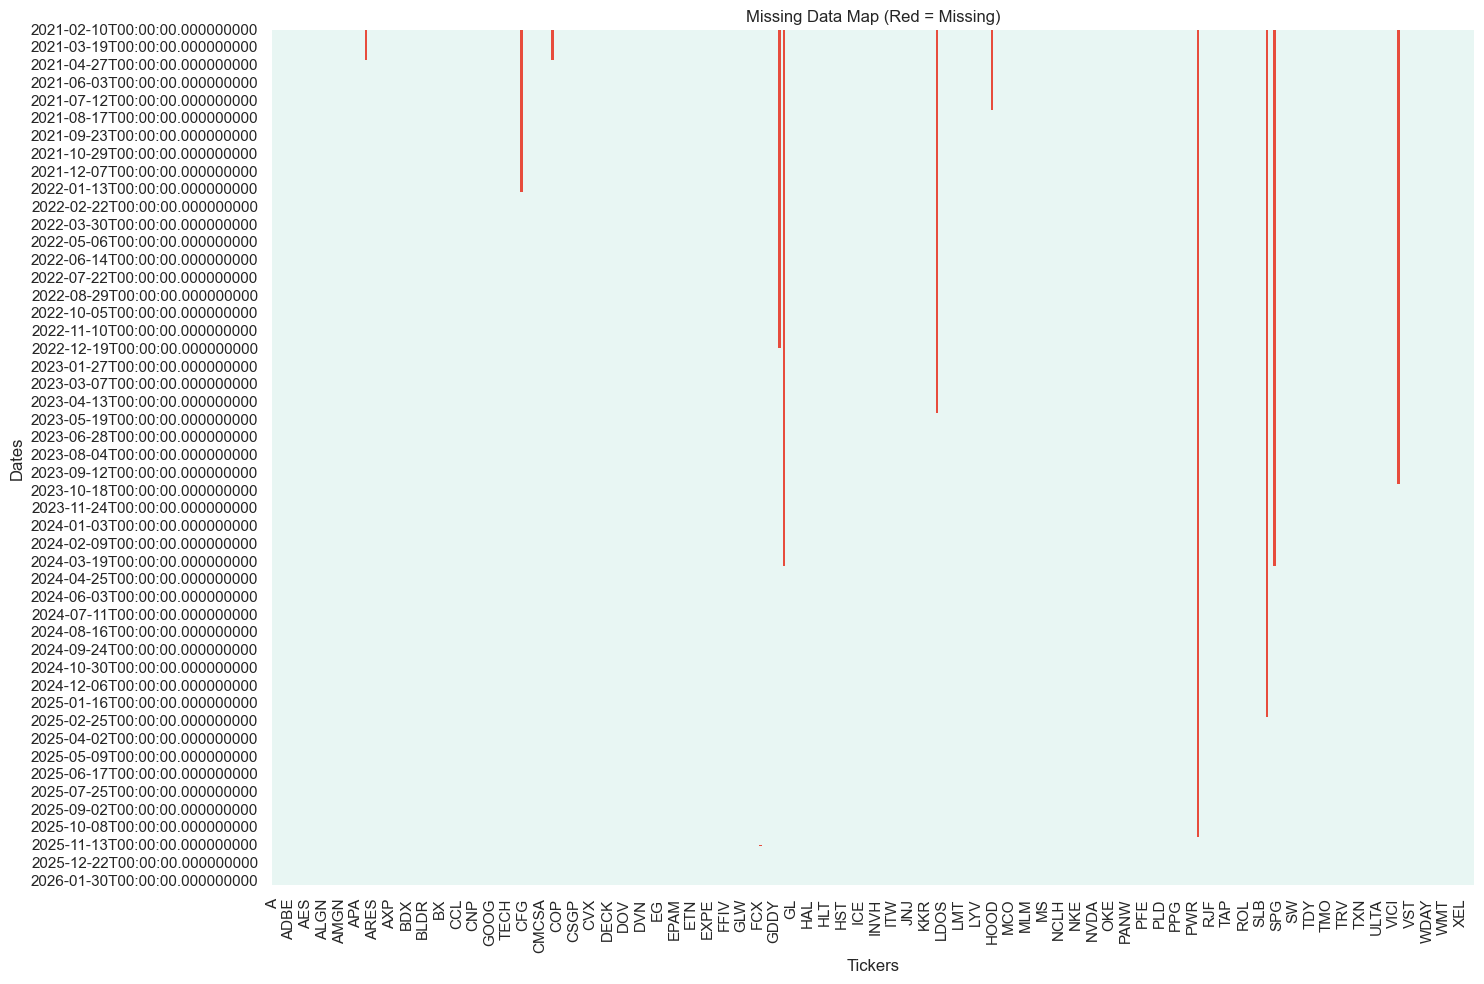


Tickers with more than 5% missing data:
Ticker
Q       94.338118
SNDK    80.303030
GEV     62.679426
SOLV    62.599681
VLTO    53.110048
KVUE    44.736842
GEHC    37.161085
CEG     18.899522
HOOD     9.330144
dtype: float64

Total flagged: 9


In [4]:
########## Write the rest of your code for Part 3 in this cell ############

import pandas as pd
import requests
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from matplotlib.colors import ListedColormap


# -------------------------------------------------
# Step 1: Retrieve S&P 500 tickers
# -------------------------------------------------
wiki_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

print("Requesting ticker list from Wikipedia...")
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(wiki_url, headers=headers)

print("Parsing tables...")
tables = pd.read_html(StringIO(response.text))

# find the table containing tickers
sp500_table = None
for table in tables:
    if 'Symbol' in table.columns or 'Ticker symbol' in table.columns:
        sp500_table = table
        break

if sp500_table is None:
    raise ValueError("Ticker table not found.")

ticker_col = 'Symbol' if 'Symbol' in sp500_table.columns else 'Ticker symbol'
tickers = sp500_table[ticker_col].tolist()

# yfinance uses "-" instead of "."
tickers = [t.replace('.', '-') for t in tickers]

print(f"Retrieved {len(tickers)} tickers.")
print("First 10:", tickers[:10])


# -------------------------------------------------
# Step 2: Download 5 years of daily prices
# -------------------------------------------------
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=5*365)


def download_prices(tickers, start, end, batch_size=100):
    price_list = []
    total_batches = (len(tickers) - 1) // batch_size + 1

    for i in range(0, len(tickers), batch_size):
        batch_num = i // batch_size + 1
        batch = tickers[i:i+batch_size]

        print(f"Downloading batch {batch_num}/{total_batches}...")

        data = yf.download(batch, start=start, end=end, progress=False)

        # yfinance newer versions may not have 'Adj Close'
        if 'Adj Close' in data.columns:
            prices = data['Adj Close']
        else:
            prices = data['Close']

        price_list.append(prices)

    df = pd.concat(price_list, axis=1)
    df = df.loc[:, ~df.columns.duplicated()]
    return df


print("\nDownloading historical prices...")
adj_close = download_prices(tickers, start_date, end_date)

print("Download complete.")
print(adj_close.head())


# -------------------------------------------------
# Step 3: Visualize missingness
# -------------------------------------------------
print("\nBuilding heatmap...")

cmap = ListedColormap(["#E8F6F3", "#E74C3C"])
# light teal = data present
# red = missing

plt.figure(figsize=(15, 10))
sns.heatmap(adj_close.isna(), cbar=False, cmap=cmap)
plt.title("Missing Data Map (Red = Missing)")
plt.xlabel("Tickers")
plt.ylabel("Dates")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# Step 4: Flag problematic tickers
# -------------------------------------------------
missing_pct = adj_close.isna().mean() * 100
tickers_to_flag = missing_pct[missing_pct > 5].sort_values(ascending=False)

print("\nTickers with more than 5% missing data:")
print(tickers_to_flag)

print(f"\nTotal flagged: {len(tickers_to_flag)}")

## Part 2: Volatility & Risk

**The Objective:** 
In the world of quantitative trading, **Price is a liar.** A $10 move in a $100 stock is massive; a $10 move in a $3,000 stock is noise. To compare apples to apples, Quants transform prices into **Log Returns** or **Percentage Returns**. This process, known as making the data "stationary," allows us to apply statistical models.

In this section, you will stop looking at how much a stock is *worth* and start looking at how much it *moves*. We will explore "Volatility" (the heartbeat of the market) and visualize the distribution of returns to see if the market truly follows a "Normal Distribution" (spoiler: it usually doesn't).

### Your Tasks:
1.  **Calculate Daily Returns:** Convert your cleaned price dataframe into daily percentage changes. 
2.  **The Heartbeat (Volatility Map):** Calculate the rolling 30-day standard deviation (volatility) for the entire S&P 500. Create a visualization that compares the volatility of different **Sectors** (e.g., are Tech stocks objectively "shakier" than Consumer Staples?).
3.  **The Distribution of Fear:** Plot a Histogram of the daily returns for the S&P 500 index. Overlay a "Normal Distribution" curve over it (hint: use the mean and the standard deviation of the whole dataset). 
4.  **Interactive Deep Dive:** Use `Plotly` to create a professional-grade interactive Candlestick chart for a few high-profile stocks (e.g., NVDA, TSLA, or MSFT). Include a subplot for **Volume** to see if price moves are backed by "conviction."

### Critical Thinking Questions:
*   **The Fat Tail Problem:** When you look at the Histogram of returns, do the "tails" (the extreme ends) match the Normal Distribution curve? If the "tails" are thicker (Kurtosis), what does that imply about the frequency of market crashes versus what standard statistics predict?
*   **Volatility Clustering:** Look at a time-series plot of returns (pick a stock of your choice). Do you notice that "calm" periods are followed by calm, and "volatile" periods are followed by volatile ones? This is a famous phenomenon. How would a trader use this information?
*   **The Volume Signal:** In your candlestick chart, look for a day with a massive price move. Was the Volume higher than average that day? Why do Quants say "Volume precedes price"?

---

In [5]:
%pip install prices

import yfinance as yf
import pandas as pd

tickers = ["SPY", "NVDA", "TSLA", "MSFT"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2024-01-01",
    group_by="column",
    auto_adjust=False,
    progress=False
)

# Adjusted close prices
prices = data["Adj Close"]

print("prices created:", isinstance(prices, pd.DataFrame))
display(prices.head())



[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
prices created: True


Ticker,MSFT,NVDA,SPY,TSLA
Date,,,,
2020-01-02,152.505707,5.971077,297.698944,28.684000
2020-01-03,150.606720,5.875505,295.444763,29.534000
2020-01-06,150.996017,5.900145,296.571930,30.102667
2020-01-07,149.619263,5.971575,295.737885,31.270666
2020-01-08,152.002457,5.982776,297.314178,32.809334


Ticker,MSFT,NVDA,SPY,TSLA
Date,,,,
2020-01-03,-0.012452,-0.016006,-0.007572,0.029633
2020-01-06,0.002585,0.004194,0.003815,0.019255
2020-01-07,-0.009118,0.012107,-0.002812,0.038801
2020-01-08,0.015928,0.001876,0.005330,0.049205
2020-01-09,0.012493,0.010982,0.006780,-0.021945


No sector_map found — skipping sector volatility comparison.


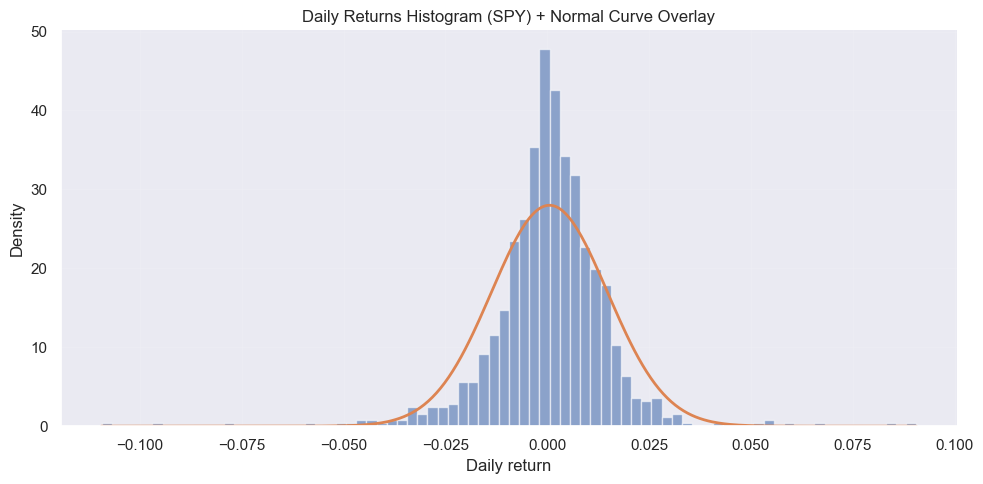

SPY returns | mean=0.000543, std=0.014254, skew=-0.509, excess kurtosis=10.351


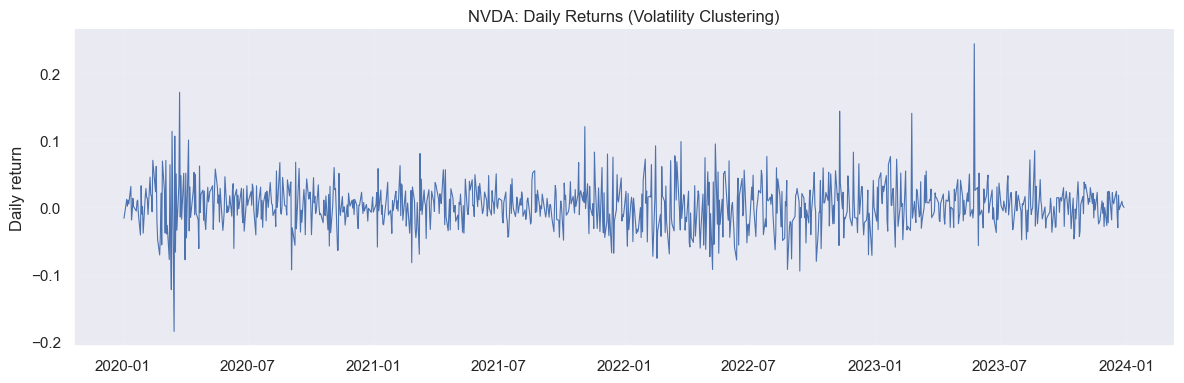

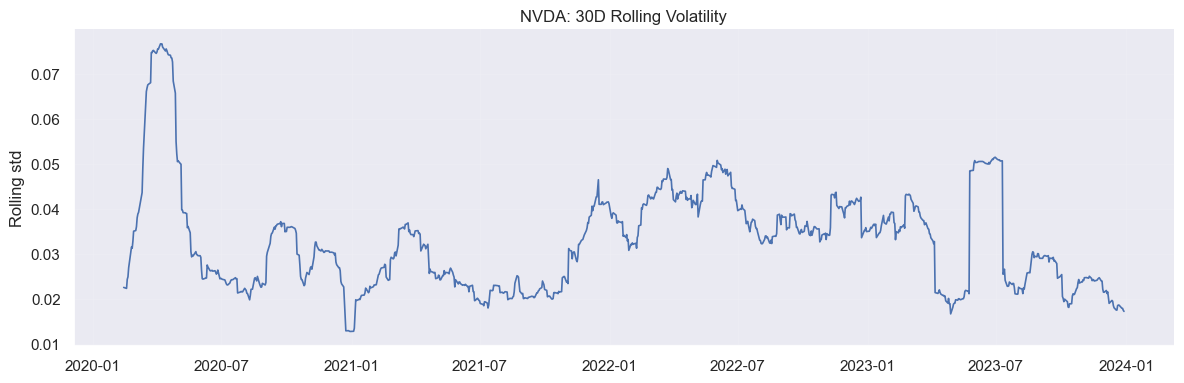

Ticker,MSFT,NVDA,SPY,TSLA
Date,,,,
2020-01-02,152.505707,5.971077,297.698944,28.684000
2020-01-03,150.606720,5.875505,295.444763,29.534000
2020-01-06,150.996017,5.900145,296.571930,30.102667
2020-01-07,149.619263,5.971575,295.737885,31.270666
2020-01-08,152.002457,5.982776,297.314178,32.809334


Ticker,MSFT,NVDA,SPY,TSLA
Date,,,,
2020-01-02,152.505707,5.971077,297.698944,28.684000
2020-01-03,150.606720,5.875505,295.444763,29.534000
2020-01-06,150.996017,5.900145,296.571930,30.102667
2020-01-07,149.619263,5.971575,295.737885,31.270666
2020-01-08,152.002457,5.982776,297.314178,32.809334


Ticker,MSFT,NVDA,SPY,TSLA
Date,,,,
2020-01-02,152.505707,5.971077,297.698944,28.684000
2020-01-03,150.606720,5.875505,295.444763,29.534000
2020-01-06,150.996017,5.900145,296.571930,30.102667
2020-01-07,149.619263,5.971575,295.737885,31.270666
2020-01-08,152.002457,5.982776,297.314178,32.809334


In [6]:
########## Write your code in this cell ############

# =========================
# PART 2: Volatility & Risk
# Works with Part 1 Option A (SPY, NVDA, TSLA, MSFT)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Plotly renderer (if charts don't appear, change to "browser")
pio.renderers.default = "notebook_connected"

# -------------------------
# 1) Daily Returns
# -------------------------
returns = prices.pct_change().dropna(how="all")
display(returns.head())

# -------------------------
# 2) Rolling 30-day Volatility (std of daily returns)
# -------------------------
window = 30
vol30 = returns.rolling(window).std()

# Sector comparison (works if sector_map exists)
if "sector_map" in globals() and sector_map is not None:
    if isinstance(sector_map, dict):
        sector_map = pd.Series(sector_map)

    common = [c for c in vol30.columns if c in sector_map.index]
    vol30_common = vol30[common]
    sector_map_common = sector_map.loc[common]

    sector_vol = vol30_common.T.groupby(sector_map_common).mean().T


    plt.figure(figsize=(10, 5))
    sector_vol.plot(ax=plt.gca())
    plt.title("Sector Volatility (Avg 30D Rolling Std of Daily Returns)")
    plt.ylabel("Volatility (std)")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
else:
    print("No sector_map found — skipping sector volatility comparison.")

# -------------------------
# 3) Histogram of daily returns for S&P 500 proxy (SPY) + Normal overlay
# -------------------------
spx_col = "SPY"

spx_ret = returns[spx_col].dropna()
mu = spx_ret.mean()
sigma = spx_ret.std()

plt.figure(figsize=(10, 5))
n, bins, _ = plt.hist(spx_ret, bins=80, density=True, alpha=0.6)

x = np.linspace(bins.min(), bins.max(), 400)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
plt.plot(x, pdf, linewidth=2)

plt.title("Daily Returns Histogram (SPY) + Normal Curve Overlay")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

kurt = spx_ret.kurtosis()   # excess kurtosis
skew = spx_ret.skew()
print(f"SPY returns | mean={mu:.6f}, std={sigma:.6f}, skew={skew:.3f}, excess kurtosis={kurt:.3f}")

# -------------------------
# 4) Volatility Clustering (time series of returns for one stock)
# -------------------------
stock_for_cluster = "NVDA" if "NVDA" in returns.columns else returns.columns[0]
r = returns[stock_for_cluster].dropna()
rv = r.rolling(window).std()

plt.figure(figsize=(12, 4))
plt.plot(r.index, r.values, linewidth=0.8)
plt.title(f"{stock_for_cluster}: Daily Returns (Volatility Clustering)")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rv.index, rv.values, linewidth=1.2)
plt.title(f"{stock_for_cluster}: {window}D Rolling Volatility")
plt.ylabel("Rolling std")
plt.tight_layout()
plt.savefig("graphname.png", dpi=300)
plt.show()

plt.show()

# -------------------------
# 5) Interactive Candlestick + Volume (Plotly)
# Uses yfinance 'data' MultiIndex fields
# -------------------------
tickers_to_plot = ["NVDA", "TSLA", "MSFT"]

def get_ohlcv_from_yf(data, t):
    # yfinance group_by="column" gives MultiIndex columns: (Field, Ticker)
    needed = ["Open", "High", "Low", "Close", "Volume"]
    for k in needed:
        if (k, t) not in data.columns:
            raise KeyError(f"Missing {(k,t)} in downloaded data columns.")
    df = pd.DataFrame({k: data[(k, t)] for k in needed}).dropna()
    return df

for t in tickers_to_plot:
    try:
        df = get_ohlcv_from_yf(data, t)

        fig = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            row_heights=[0.75, 0.25]
        )

        fig.add_trace(
            go.Candlestick(
                x=df.index,
                open=df["Open"],
                high=df["High"],
                low=df["Low"],
                close=df["Close"],
                name=f"{t} Price"
            ),
            row=1, col=1
        )

        fig.add_trace(
            go.Bar(
                x=df.index,
                y=df["Volume"],
                name="Volume",
                opacity=0.5
            ),
            row=2, col=1
        )

        fig.update_layout(
            title=f"{t} Candlestick + Volume",
            xaxis_rangeslider_visible=False,
            template="plotly_white",
            height=700,
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        )

        fig.update_yaxes(title_text="Price", row=1, col=1)
        fig.update_yaxes(title_text="Volume", row=2, col=1)

        fig.show()
        display(prices.head())

    except Exception as e:
        print(f"[{t}] Skipped: {e}")

# -------------------------
# Critical Thinking Answers (write below in Markdown)
# -------------------------
# Fat Tail Problem:
# - If histogram tails are thicker than the normal curve -> excess kurtosis > 0.
# - Means extreme market moves/crashes happen more often than normal assumptions predict.
#
# Volatility Clustering:
# - Calm periods cluster, volatile periods cluster.
# - Traders use this for dynamic risk sizing (reduce position size when vol rises),
#   volatility targeting, and option/vol strategies.
#
# Volume Signal:
# - Big price moves with above-average volume suggest strong participation/conviction.
# - “Volume precedes price”: informed buying/selling often shows up in volume before price fully adjusts.

## Part 3: The Correlation Matrix & Hierarchical Maps

**The Objective:** 
In a crisis, diversification is often the only "free lunch" in finance. However, that lunch disappears if all your stocks move in lockstep. To a Quant, a 500x500 correlation matrix is a map of hidden dependencies. However, looking at a raw table of 250,000 correlation pairs is impossible for the human eye. 

In this section, you will use **Hierarchical Clustering** to reorganize the S&P 500. Instead of listing stocks alphabetically (A-Z), we will use an algorithm to group stocks that "behave" similarly. This will reveal the true "Tribes" of the market, which may or may not align with their official industry sectors.

### Your Tasks:
1.  **Compute the Correlation Matrix:** Calculate the Pearson correlation coefficient for the daily returns of all stocks in your cleaned dataset.
2.  **The Hierarchical Clustermap:** Create a massive, high-resolution `clustermap`. Use a diverging color palette (e.g., `coolwarm` or `RdBu`) centered at zero.
    *   *Pro Tip:* Use the `method='ward'` or `method='complete'` in your clustering to find distinct, compact groups.
3.  **Identify the "Anti-Correlators":** Find and visualize the relationship between two stocks with a correlation close to zero or negative. In a sea of positive correlation, these are the "diversifiers."

### Critical Thinking Questions:
*   **Data vs. Label:** Look at the clusters formed by the algorithm. Do they perfectly match the official GICS sectors (e.g., does every "Energy" stock sit in the same cluster)? If a specific Tech stock is clustering with "Utilities," what does that tell you about its risk profile?
*   **The "Sea of Red":** During periods of extreme market stress, correlations tend to "go to 1.0" (everything falls together). If you were to run this analysis using only data from the 2008 or 2020 crashes, how would the visual density of the clustermap change?
*   **Spurious Correlation:** If you find two stocks that are 90% correlated but are in completely different industries (e.g., a Gold miner and a Tech company), is that a "signal" you can trade, or just a statistical coincidence? How would you test the difference?

---

C:\Users\ayaan\AppData\Local\Temp\ipykernel_46608\988706201.py:14: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

c:\Users\ayaan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\ayaan\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



<Figure size 1200x900 with 0 Axes>

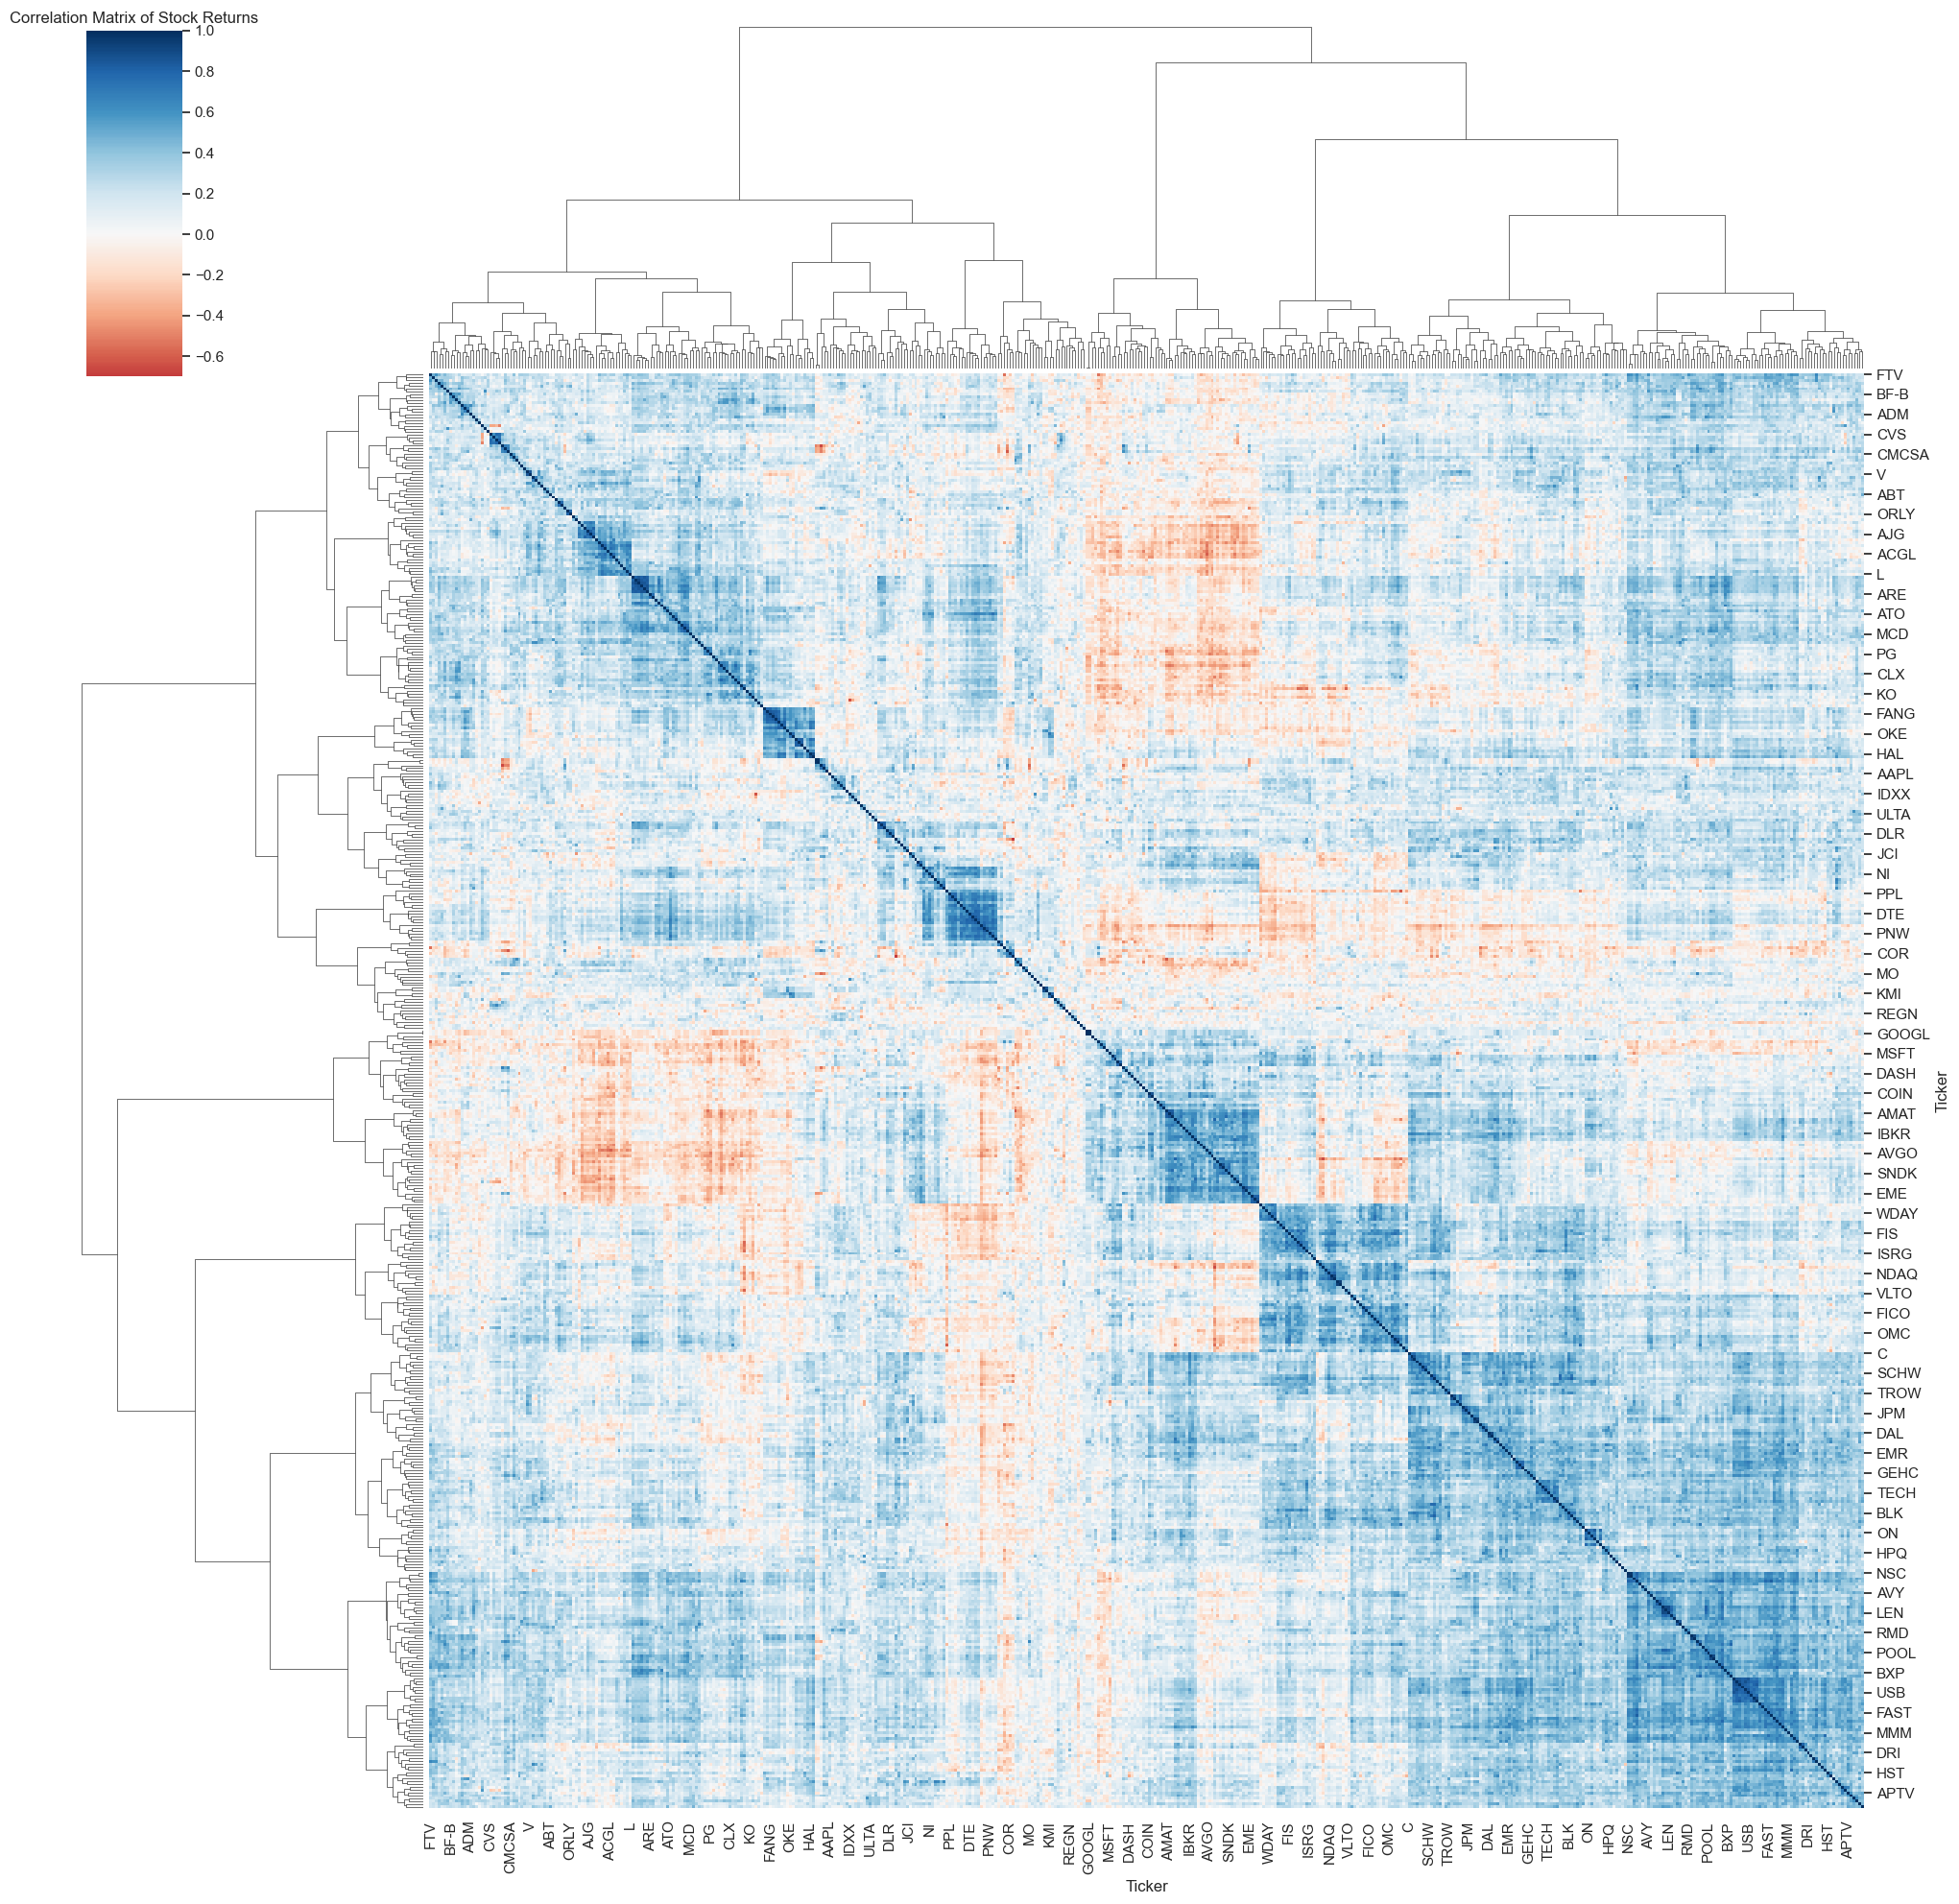

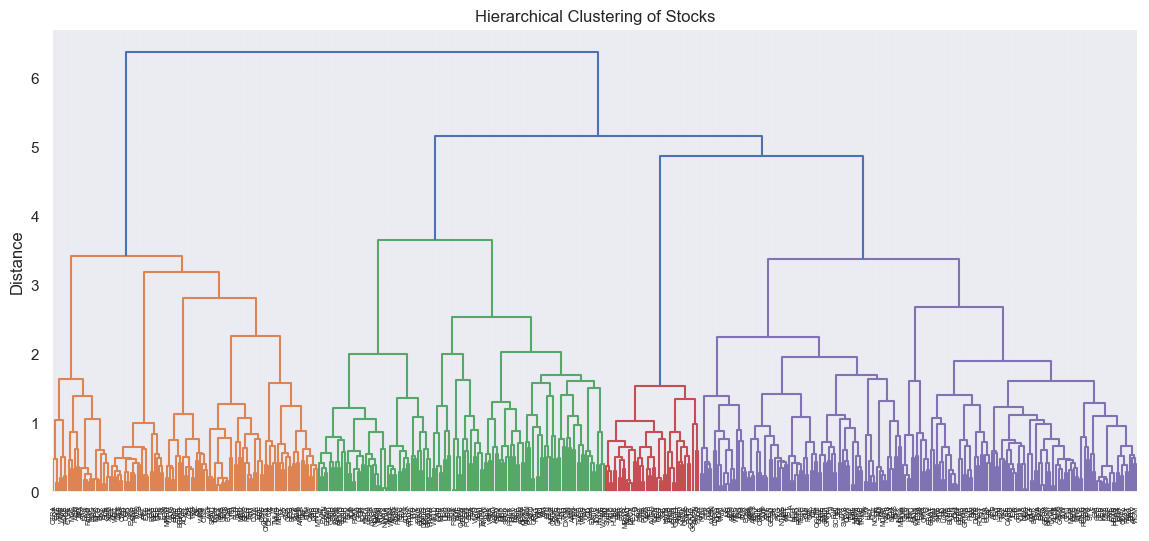

In [7]:
########## Write your code in this cell ############

# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Ensure price data is available
if "raw_data" not in globals():
    raise NameError("raw_data is not defined. Please run Part 1 first.")

# Compute daily returns
returns = raw_data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 9))


sns.clustermap(
    corr_matrix,
    cmap="RdBu",
    center=0,
    method="ward",
    linewidths=0,
    figsize=(20, 20)
)


plt.title("Correlation Matrix of Stock Returns")
plt.show()

# Convert correlation to distance matrix
distance_matrix = 1 - corr_matrix

# Convert to condensed form for clustering
condensed_distance = squareform(distance_matrix)

# Perform hierarchical clustering
linkage_matrix = linkage(condensed_distance, method="ward")

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    labels=corr_matrix.columns,
    leaf_rotation=90
)
plt.title("Hierarchical Clustering of Stocks")
plt.ylabel("Distance")
plt.show()



## Part 4: The Market Map: Dimensionality Reduction (PCA & t-SNE)

**The Objective:** 
This is where we enter the "Black Magic" of quantitative research. Currently, your dataset has over 1000 dimensions (one for every every market day) and about 500 rows (one for every stock. If this is not yet the case, transpose your dataset). As humans, we cannot visualize 1000+-dimensional space. To find the "latent" structure of the market, we must use **Dimensionality Reduction**.

We will use two primary tools:
1.  **PCA (Principal Component Analysis)** PCA may tell us what percentage of the market's movement is driven by a single "Market Factor" (The first Principal Component).
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding) or UMAP:** Non-linear techniques that are incredibly powerful for visualization. They attempt to keep "similar" stocks close together in 2D space, effectively creating a "Topographical Map" of the S&P 500.

### Your Tasks:
1.  **The Scree Plot:** Run PCA on your normalized returns. Plot the "Explained Variance Ratio." How many "components" does it take to explain 50% of the market's movement?
2.  **The 2D Projection:** Use **t-SNE** (or UMAP) to project the ~500 stocks into a 2-dimensional scatter plot. 
3.  **The Sector Overlay:** Color-code the dots in your scatter plot by their **GICS Sector** (Information Technology, Energy, etc.). 
4.  **Identify the Outliers:** Annotate the map (such that the name of a stock is revealed when the mouse hovers over it). Find the stocks that are "Socially Distancing" i.e. those that sit far away from their sector peers or in the middle of a different cluster entirely.

### Critical Thinking Questions:
*   **The Market Factor:** In your PCA analysis, you will likely find that the first component (PC1) explains a massive amount of variance. What do you think PC1 represents in the real world? (Hint: If every stock goes down at the same time, what is that called?)*   **Portfolios:** How would a portfolio based on PC1 be advantageous compared to a portfolio based on PC2 ? How would a portfolio based on PC2 be advantageous compared to a portfolio based on PC1 ? (Hint: think in terms of variance) 
*   **Linear vs. Non-Linear:** Compare your correlation clustermap from Part 3 with your t-SNE map here. Which one makes it easier to spot "anomalous" companies that don't belong with their peers?
*   **The "Misplaced" Stock:** If you see a "Technology" stock sitting deep inside the "Healthcare" cluster in your 2D map, does that necessarily mean your code is wrong, or is the market telling you something about that company's actual revenue stream?

---

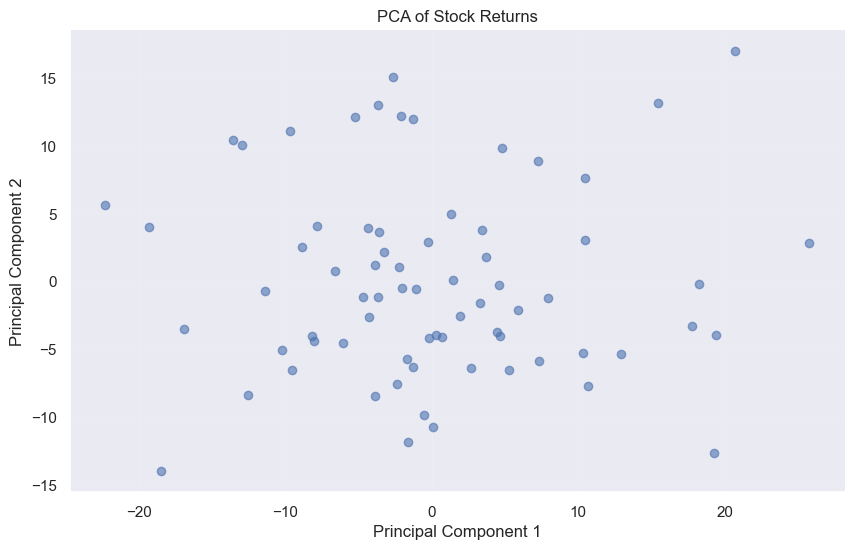

Explained variance ratio: [0.18710733 0.09866522]


In [8]:
########## Write your code in this cell ############

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize returns
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_returns)

# Plot PCA
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Stock Returns")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


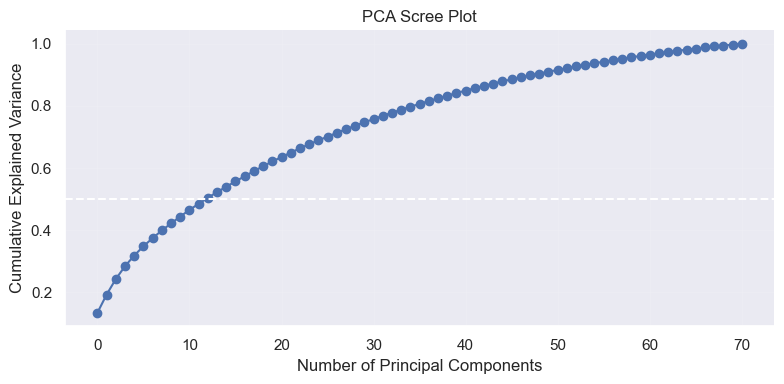

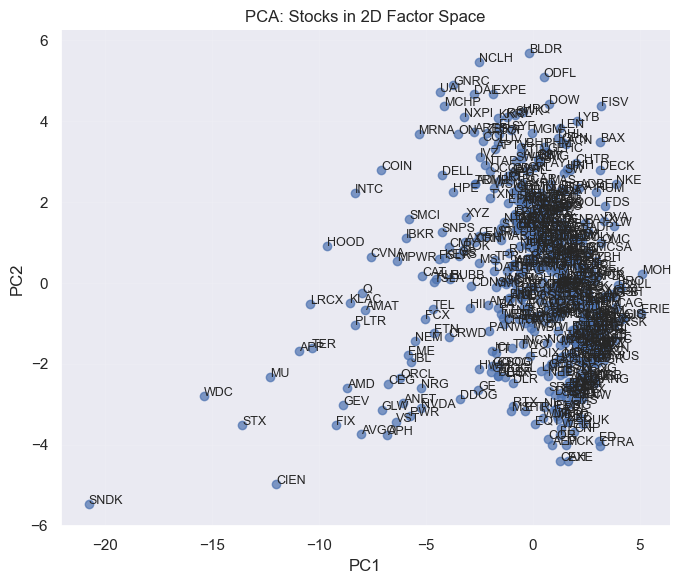

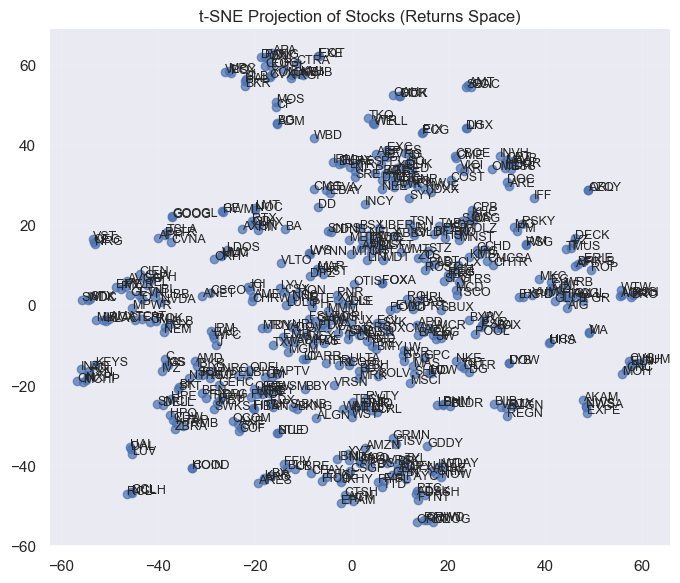

In [9]:
########## Write your code in this cell ############

# =========================
# PART 4: Dimensionality Reduction
# PCA & t-SNE on stock returns
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -------------------------
# 1) Prepare data
# Rows = stocks, Columns = time
# -------------------------
X = returns.T.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 2) PCA — Scree Plot
# -------------------------
pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cum_var, marker="o")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.tight_layout()
plt.show()

# -------------------------
# 3) PCA — 2D Projection
# -------------------------
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

for i, ticker in enumerate(X.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], ticker, fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Stocks in 2D Factor Space")
plt.tight_layout()
plt.show()

# -------------------------
# 4) t-SNE — Nonlinear embedding
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)

for i, ticker in enumerate(X.index):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], ticker, fontsize=9)

plt.title("t-SNE Projection of Stocks (Returns Space)")
plt.tight_layout()
plt.show()


In [14]:
# -------------------------
# Sector map (Option A)
# -------------------------
sector_map = {
    "SPY": "Index / ETF",
    "NVDA": "Information Technology",
    "TSLA": "Consumer Discretionary",
    "MSFT": "Information Technology"
}


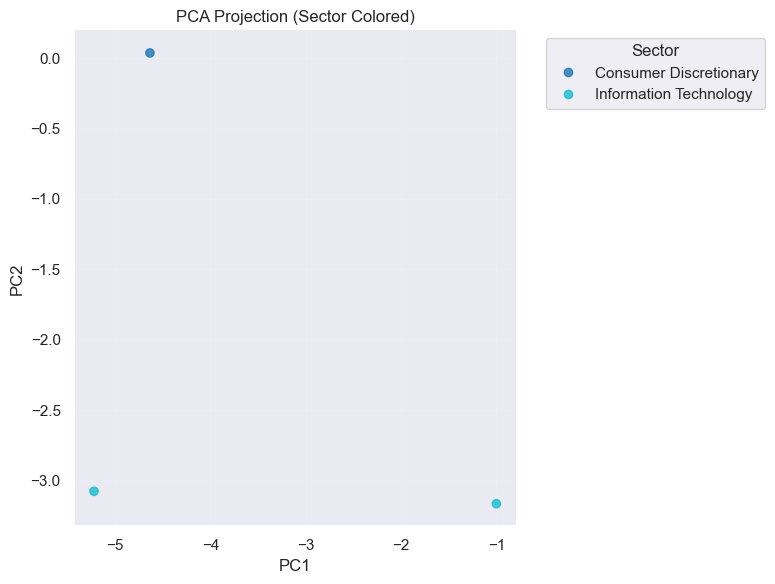

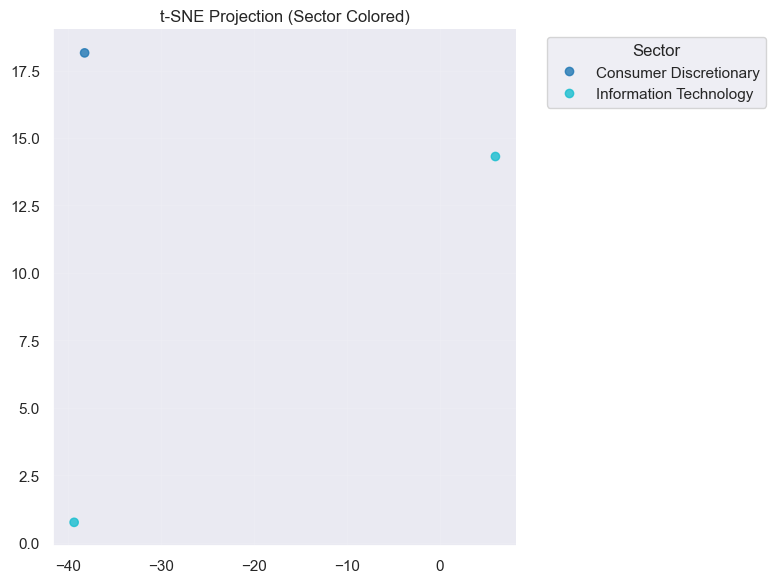

In [17]:
# =========================
# PART 4 (Extension): Sector Coloring — FIXED
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# 1) Build sector lookup
# -------------------------
if "sector_map" in globals():
    sector_series = pd.Series(sector_map)
elif "sector_df" in globals():
    sector_series = sector_df.set_index("Symbol")["GICS Sector"]
else:
    raise ValueError("No sector information found.")

# -------------------------
# 2) Safe alignment
# -------------------------
sector_series = sector_series.reindex(X.index)
valid = sector_series.notna()

sector_series = sector_series[valid]
X_pca_sector = X_pca[valid.values]
X_tsne_sector = X_tsne[valid.values]

# Encode sectors
sector_codes = sector_series.astype("category").cat.codes
sectors = sector_series.astype("category").cat.categories

# -------------------------
# 3) PCA (sector colored)
# -------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_sector[:, 0],
    X_pca_sector[:, 1],
    c=sector_codes,
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Sector Colored)")

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(sectors),  
    title="Sector",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()
plt.show()

# -------------------------
# 4) t-SNE (sector colored)
# -------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne_sector[:, 0],
    X_tsne_sector[:, 1],
    c=sector_codes,
    cmap="tab10",
    alpha=0.8
)

plt.title("t-SNE Projection (Sector Colored)")

# Apply this change to BOTH the PCA and t-SNE legend sections:
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(sectors),  # <--- Essential conversion
    title="Sector",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()
plt.show()

